<a href="https://colab.research.google.com/github/yaduk883/Iris_Clustering/blob/main/Iris_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning - Clustering
## Iris Dataset from sklearn

**Objective:** Apply and compare KMeans and Hierarchical clustering algorithms on the Iris dataset to discover natural groupings among flowers.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

---
## 1. Loading and Preprocessing

In [22]:
data = load_iris() # load iris dataset from sklearn


df = pd.DataFrame(data.data, columns=data.feature_names) # create dataframe with feature columns only (drop species - unsupervised problem)

print('Shape :', df.shape)
print('Columns :', df.columns.tolist())
print('\nSpecies column dropped — this is a clustering problem (no labels used)')
df.head()

Shape : (150, 4)
Columns : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Species column dropped — this is a clustering problem (no labels used)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [23]:
print('Statistical Summary :')# statistical summary
df.describe()

Statistical Summary :


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [24]:
print('Missing values :', df.isnull().sum().sum()) # check missing values
print('No missing values — dataset is clean!')

Missing values : 0
No missing values — dataset is clean!


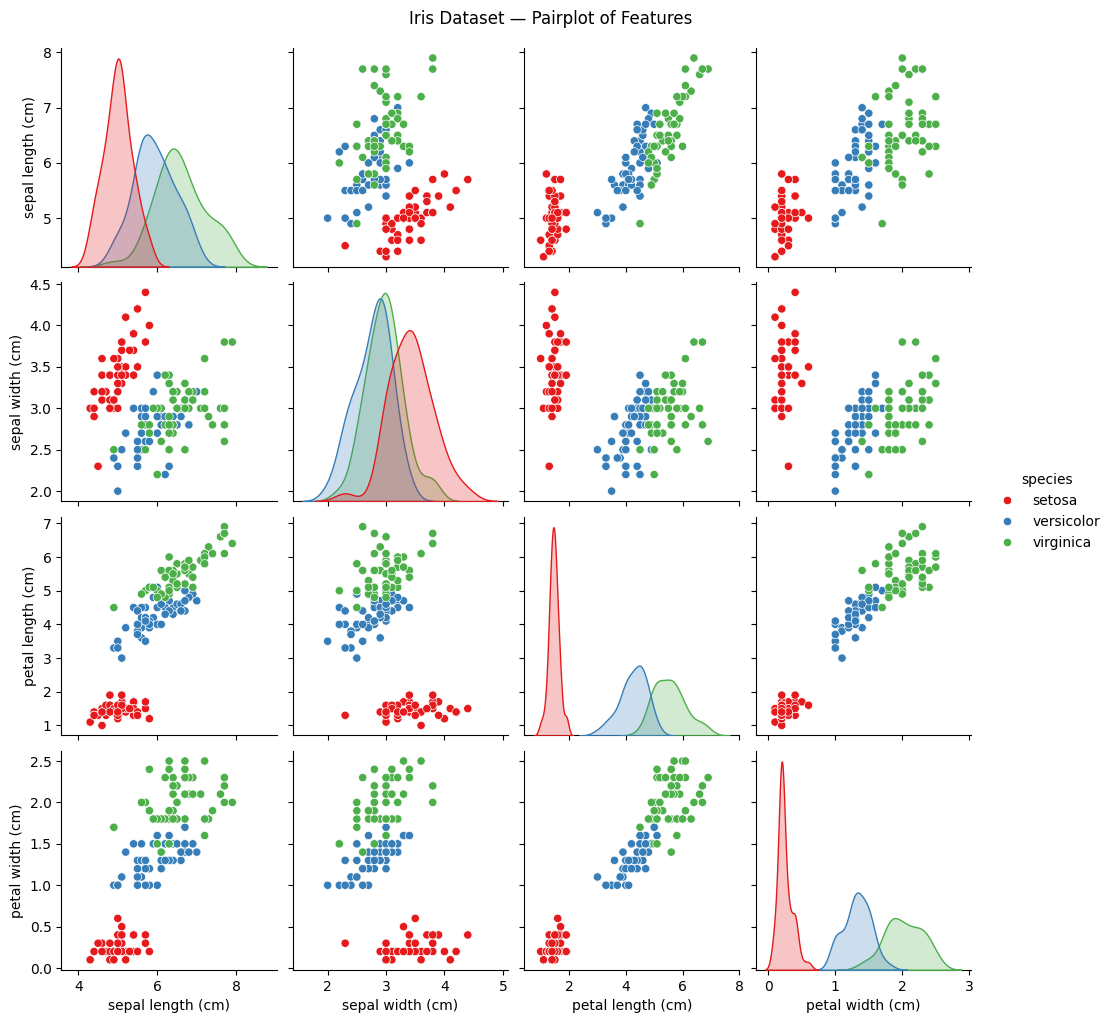

In [25]:
df_vis = df.copy() # pairplot to understand feature distributions
df_vis['species'] = data.target_names[data.target]
sns.pairplot(df_vis, hue='species', palette='Set1')
plt.suptitle('Iris Dataset — Pairplot of Features', y=1.02)
plt.show()

In [26]:
ss = StandardScaler()
X = ss.fit_transform(df)

print('Scaling done using StandardScaler')
print('Mean after scaling (should be ~0) :', X.mean(axis=0).round(4))
print('Std after scaling  (should be ~1) :', X.std(axis=0).round(4))
# feature scaling using StandardScaler
# petal length ranges from 1 to 6.9 while petal width ranges from 0.1 to 2.5
# scaling ensures equal contribution from all features during distance calculation

Scaling done using StandardScaler
Mean after scaling (should be ~0) : [-0. -0. -0. -0.]
Std after scaling  (should be ~1) : [1. 1. 1. 1.]


---
## 2. Clustering Algorithm Implementation

### Algorithm 1 - KMeans Clustering

**How this works:**
KMeans partitions the data into K clusters by minimizing the within-cluster sum of squares. It starts by placing K centroids randomly, then alternates between two steps — assigning each point to the nearest centroid, and recalculating centroids as the mean of assigned points. This repeats until centroids stop moving.

**Why this is suitable for Iris:**
The Iris dataset has 3 natural species groups, ma![image.png] king K=3 a natural choice. The clusters in Iris are roughly spherical and similar in size, which aligns well with KMeans' assumption of equal, globular clusters. It is also fast and scalable, ideal for a small 150-sample dataset.

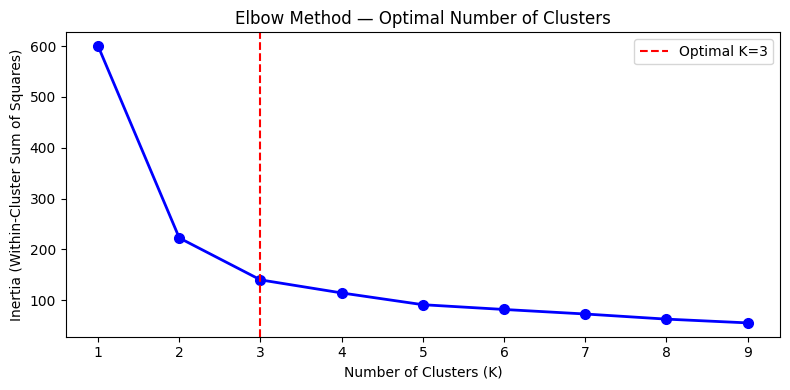

In [27]:
inertias = [] # elbow method to find optimal K
k_range  = range(1, 10)

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=7)
plt.axvline(x=3, color='red', linestyle='--', label='Optimal K=3')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.legend()
plt.tight_layout()
plt.show()

# the elbow clearly appears at K=3, confirming 3 is the right number of clusters

In [28]:
km = KMeans(n_clusters=3, random_state=42, n_init=10) # apply KMeans with K=3
km_labels = km.fit_predict(X)

print('KMeans Clustering Results :')
print('  Cluster sizes :', pd.Series(km_labels).value_counts().sort_index().to_dict())
print('  Inertia       :', round(km.inertia_, 4))
print('  Silhouette Score :', round(silhouette_score(X, km_labels), 4))

KMeans Clustering Results :
  Cluster sizes : {0: 53, 1: 50, 2: 47}
  Inertia       : 139.8205
  Silhouette Score : 0.4599


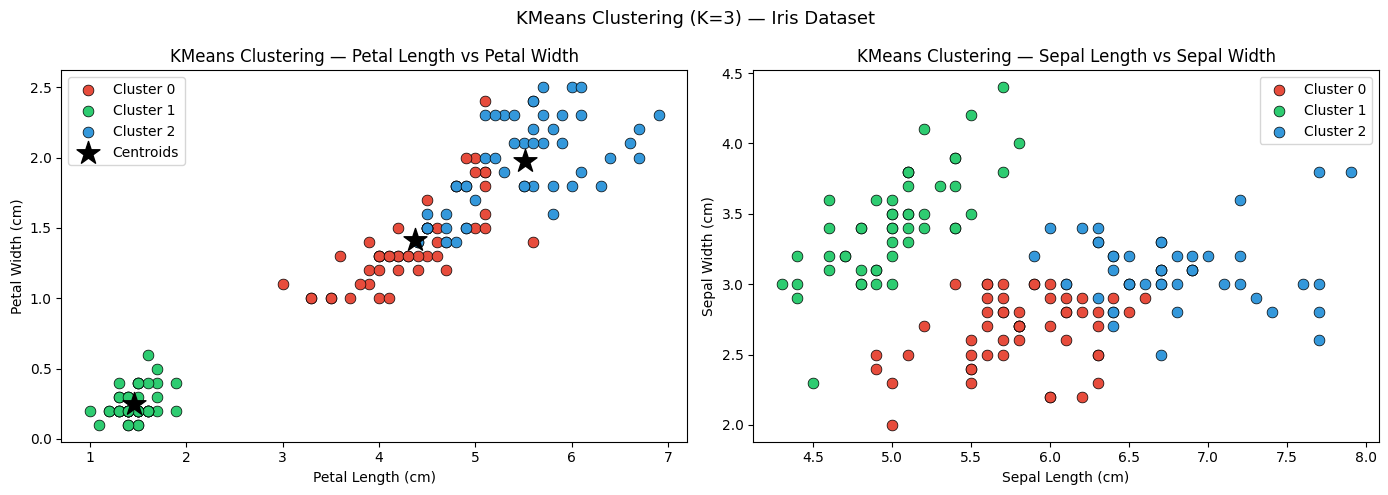

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # visualize KMeans clusters using petal length vs petal width
# (most discriminating features)

colors = ['#E74C3C', '#2ECC71', '#3498DB']

for cluster in range(3): # cluster plot
    mask = km_labels == cluster
    axes[0].scatter(df['petal length (cm)'][mask],
                    df['petal width (cm)'][mask],
                    c=colors[cluster], label=f'Cluster {cluster}',
                    s=60, edgecolors='black', linewidths=0.5)


centroids_orig = ss.inverse_transform(km.cluster_centers_) # plot centroids (inverse transform to original scale)
axes[0].scatter(centroids_orig[:, 2], centroids_orig[:, 3],
                marker='*', s=300, c='black', label='Centroids', zorder=5)
axes[0].set_title('KMeans Clustering — Petal Length vs Petal Width')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].legend()

# sepal plot
for cluster in range(3):
    mask = km_labels == cluster
    axes[1].scatter(df['sepal length (cm)'][mask],
                    df['sepal width (cm)'][mask],
                    c=colors[cluster], label=f'Cluster {cluster}',
                    s=60, edgecolors='black', linewidths=0.5)
axes[1].set_title('KMeans Clustering — Sepal Length vs Sepal Width')
axes[1].set_xlabel('Sepal Length (cm)')
axes[1].set_ylabel('Sepal Width (cm)')
axes[1].legend()

plt.suptitle('KMeans Clustering (K=3) — Iris Dataset', fontsize=13)
plt.tight_layout()
plt.show()

# Observation:
# KMeans clearly separates Cluster 0 (small petals - setosa) from the rest.
# Clusters 1 and 2 (versicolor and virginica) show slight overlap on petal features.
# Silhouette score of 0.46 confirms reasonably well-defined clusters.

---
### Algorithm 2 : Hierarchical Clustering

**How this works:**
Hierarchical (Agglomerative) Clustering starts by treating each data point as its own cluster. It then repeatedly merges the two closest clusters based on a linkage criterion (Ward linkage minimizes the total within-cluster variance after merging) until all points belong to one cluster. The result can be visualized as a dendrogram - a tree diagram showing the merge sequence.

**Why this is suitable for Iris:**
Hierarchical clustering does not require specifying K in advance - the dendrogram lets us visually choose the right number of clusters by cutting at the appropriate level. The Iris dataset's 150 samples are small enough for hierarchical clustering to run efficiently, and Ward linkage works well with the compact, roughly spherical clusters in this dataset.

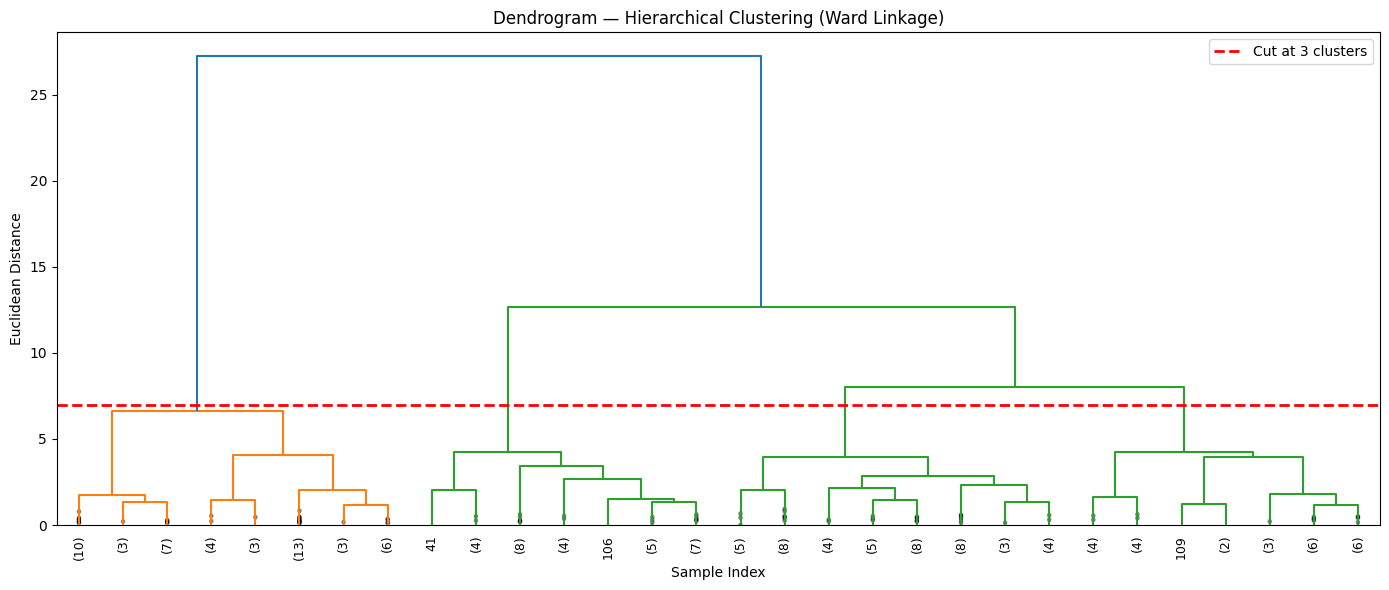

In [30]:
# dendrogram to visualize the hierarchy and choose number of clusters
linked = linkage(X, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90,
           leaf_font_size=9,
           show_contracted=True)
plt.axhline(y=7, color='red', linestyle='--', linewidth=2, label='Cut at 3 clusters')
plt.title('Dendrogram — Hierarchical Clustering (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.tight_layout()
plt.show()

# the dendrogram shows 3 clear groups when cut at distance ~7
# this confirms K=3 is the natural number of clusters in this dataset

In [31]:
# apply hierarchical clustering with 3 clusters
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X)

print('Hierarchical Clustering Results :')
print('  Cluster sizes     :', pd.Series(hc_labels).value_counts().sort_index().to_dict())
print('  Silhouette Score  :', round(silhouette_score(X, hc_labels), 4))

Hierarchical Clustering Results :
  Cluster sizes     : {0: 71, 1: 49, 2: 30}
  Silhouette Score  : 0.4467


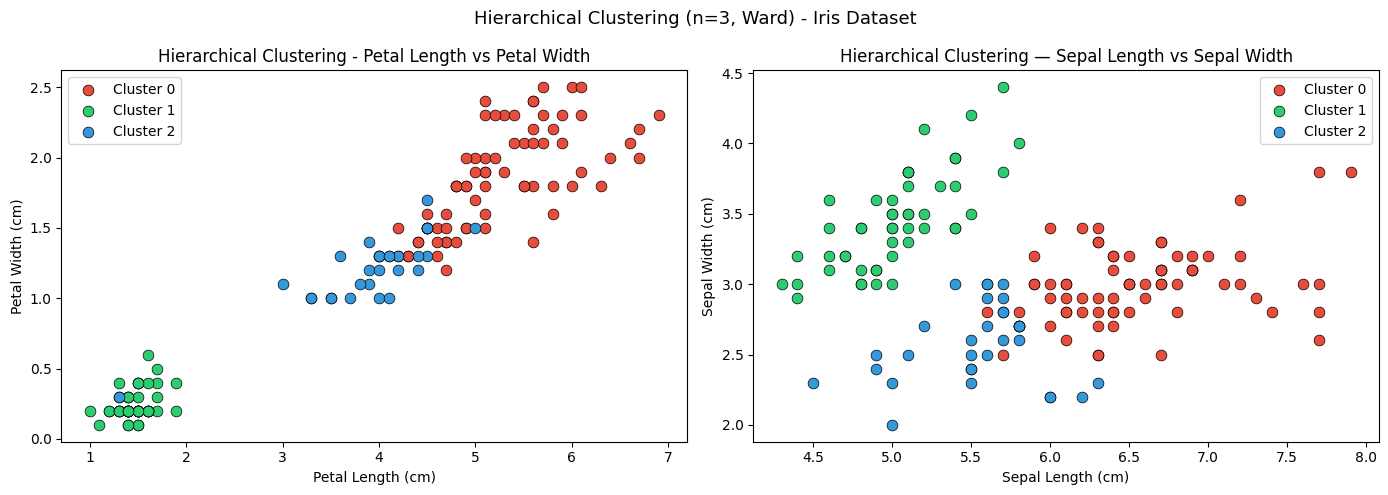

In [32]:
# visualize hierarchical clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#E74C3C', '#2ECC71', '#3498DB']

# petal plot
for cluster in range(3):
    mask = hc_labels == cluster
    axes[0].scatter(df['petal length (cm)'][mask],
                    df['petal width (cm)'][mask],
                    c=colors[cluster], label=f'Cluster {cluster}',
                    s=60, edgecolors='black', linewidths=0.5)
axes[0].set_title('Hierarchical Clustering - Petal Length vs Petal Width')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].legend()

# sepal plot
for cluster in range(3):
    mask = hc_labels == cluster
    axes[1].scatter(df['sepal length (cm)'][mask],
                    df['sepal width (cm)'][mask],
                    c=colors[cluster], label=f'Cluster {cluster}',
                    s=60, edgecolors='black', linewidths=0.5)
axes[1].set_title('Hierarchical Clustering — Sepal Length vs Sepal Width')
axes[1].set_xlabel('Sepal Length (cm)')
axes[1].set_ylabel('Sepal Width (cm)')
axes[1].legend()

plt.suptitle('Hierarchical Clustering (n=3, Ward) - Iris Dataset', fontsize=13)
plt.tight_layout()
plt.show()

# Observation:
# Hierarchical clustering also clearly separates one tight cluster (setosa - small petals).
# The other two clusters (versicolor and virginica) show slight overlap in the middle range.
# Silhouette score of 0.4467 is slightly lower than KMeans, showing KMeans fits better.

---
## Comparison - KMeans vs Hierarchical Clustering

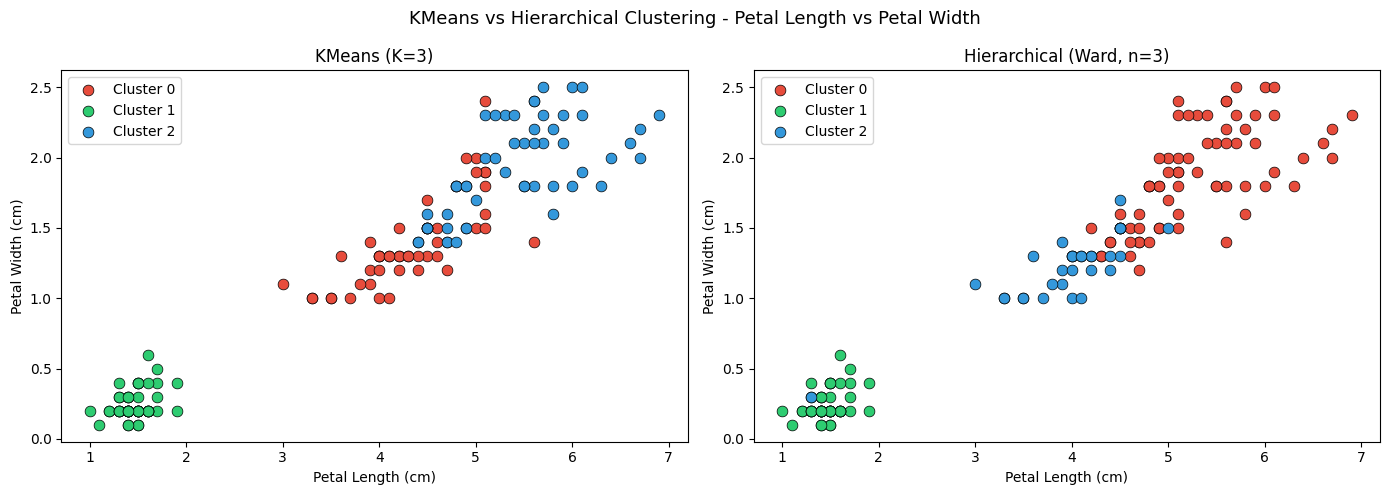

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # side by side comparison

for ax, labels, title in zip(
    axes,
    [km_labels, hc_labels],
    ['KMeans (K=3)', 'Hierarchical (Ward, n=3)']
):
    for cluster in range(3):
        mask = labels == cluster
        ax.scatter(df['petal length (cm)'][mask],
                   df['petal width (cm)'][mask],
                   c=colors[cluster], label=f'Cluster {cluster}',
                   s=60, edgecolors='black', linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')
    ax.legend()

plt.suptitle('KMeans vs Hierarchical Clustering - Petal Length vs Petal Width', fontsize=13)
plt.tight_layout()
plt.show()

In [34]:
comparison = pd.DataFrame({ # final comparison table
    'Algorithm'        : ['KMeans', 'Hierarchical (Ward)'],
    'Silhouette Score' : [
        round(silhouette_score(X, km_labels), 4),
        round(silhouette_score(X, hc_labels), 4)
    ],
    'Cluster Sizes'    : [
        str(pd.Series(km_labels).value_counts().sort_index().to_dict()),
        str(pd.Series(hc_labels).value_counts().sort_index().to_dict())
    ]
})
print('Clustering Comparison :')
print(comparison.to_string(index=False))

Clustering Comparison :
          Algorithm  Silhouette Score         Cluster Sizes
             KMeans            0.4599 {0: 53, 1: 50, 2: 47}
Hierarchical (Ward)            0.4467 {0: 71, 1: 49, 2: 30}


---
## Summary

| Algorithm | Silhouette Score | Cluster Sizes |
|-----------|-----------------|---------------|
| **KMeans (K=3)** | **0.4599** | 53, 50, 47 |
| Hierarchical (Ward) | 0.4467 | 71, 49, 30 |

**KMeans** performed slightly better with a higher silhouette score of 0.4599 and produced more balanced cluster sizes (53, 50, 47 — closely matching the true 50 samples per species). The Elbow Method clearly confirmed K=3 as optimal.

**Hierarchical Clustering** gave a slightly lower silhouette score of 0.4467 and produced unequal cluster sizes (71, 49, 30). However, it provided a valuable dendrogram visualization that independently confirmed 3 as the natural number of clusters without needing to specify K in advance.

The two algorithms were able to identify the three natural flower species groups of the Iris data set, with one tight cluster (Setosa - small petals) being perfectly segregated and the other two clusters (Versicolor and Virginica) presenting some overlap due to their natural similarities.